In [1]:
# For Kaggle — this covers most modern GPUs (T4, P100, A100)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 58.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 53.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 98.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import inception_v3
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange #pip install einops
from typing import List
import random
import math
from torchvision import datasets, transforms
from timm.utils import ModelEmaV3 #pip install timm 
from tqdm import tqdm #pip install tqdm
import torch.optim as optim
import numpy as np
from typing import Dict, List, Optional, Sequence, Tuple
from scipy.linalg import sqrtm
import os
from torchvision.models import Inception_V3_Weights

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Fashion-MNIST

In [7]:
ddpm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [8]:
ddpm_train = torchvision.datasets.FashionMNIST(
    root='/kaggle/working/data', train=True,
    download=True, transform=ddpm_transform
)

test_set = torchvision.datasets.FashionMNIST(
    root='/kaggle/working/data', train=False,
    download=True, transform=ddpm_transform
)


classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]


Extracting /kaggle/working/data/FashionMNIST/raw/train-images-idx3-ubyte.gz to /kaggle/working/data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]


Extracting /kaggle/working/data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to /kaggle/working/data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]


Extracting /kaggle/working/data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to /kaggle/working/data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 10.1MB/s]

Extracting /kaggle/working/data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to /kaggle/working/data/FashionMNIST/raw



In [ ]:
ddpm_loader = DataLoader(
    ddpm_train,
    batch_size=64,       
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [10]:
print(f"Train images: {len(ddpm_train):,} | Train batches: {len(ddpm_loader):,}")
print(f"Test images:  {len(test_set):,} | Test batches:  {len(test_loader):,}")

Train images: 60,000 | Train batches: 938
Test images:  10,000 | Test batches:  157


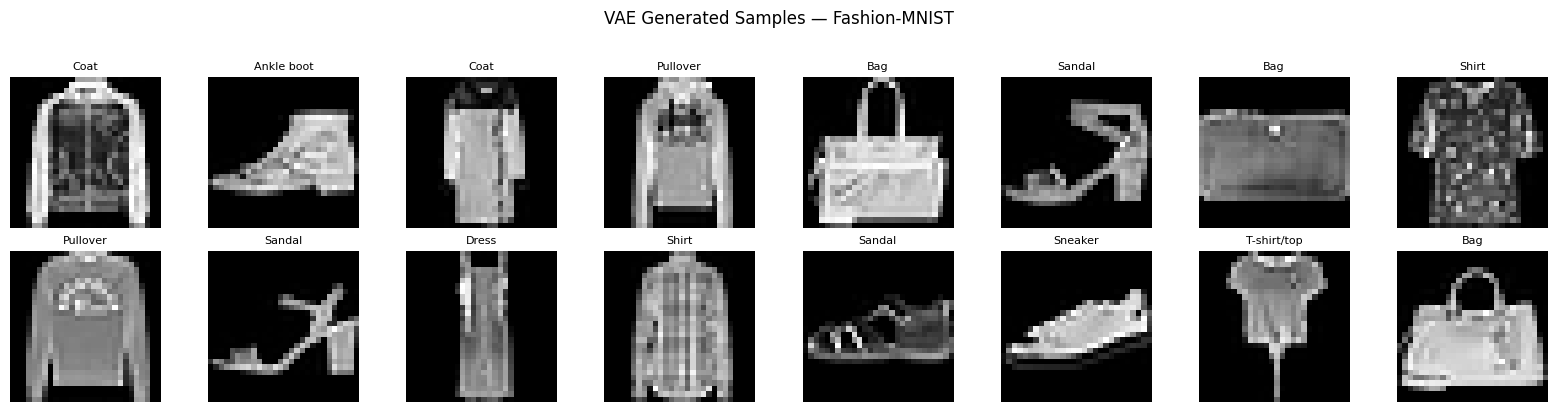

Batch shape : torch.Size([64, 1, 28, 28])
Pixel min   : -1.000
Pixel max   : 1.000


In [ ]:

def denormalize(tensor):
    """[-1,1] → [0,1] for visualization"""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(ddpm_loader))


fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).squeeze(-1).numpy()   # (28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i]], fontsize=8)
    ax.axis('off')
# plt.suptitle('CIFAR-10 Sample Batch', y=1.02)
plt.suptitle('VAE Generated Samples — Fashion-MNIST', y=1.02)

plt.tight_layout()
plt.show()

print(f"Batch shape : {images.shape}")        
print(f"Pixel min   : {images.min():.3f}")    
print(f"Pixel max   : {images.max():.3f}")   


## 2. DDPM functions

In [12]:
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)

In [13]:
class DDPM_Scheduler(nn.Module):
    def __init__(self, num_time_steps: int = 1000):
        super().__init__()
        self.beta = torch.linspace(1e-4, 0.02, num_time_steps, requires_grad=False)
        alpha = 1 - self.beta
        self.alpha = torch.cumprod(alpha, dim=0).requires_grad_(False)

    def forward(self, t):
        return self.beta[t], self.alpha[t]

In [14]:
class SinusoidalEmbeddings(nn.Module):
    def __init__(self, time_steps:int, embed_dim: int):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim)
        )
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div) #even
        embeddings[:, 1::2] = torch.cos(position * div) #Odd
        self.register_buffer('embeddings', embeddings)

    def forward(self, t):
        return self.embeddings[t.cpu()]

In [ ]:
class TimeEmbedding(nn.Module):
    """
    NEW — 2-layer MLP: Linear → SiLU → Linear.
    Paper §3.3: 'we use a Transformer sinusoidal position embedding …
    projected with two fully connected layers.'
    One instance per resolution level (channels differ per level).
    """
    def __init__(self, embed_dim: int, out_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, out_dim),
            nn.SiLU(),                    
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, t_emb):
        return self.mlp(t_emb)           

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, C: int, num_groups: int, dropout_prob: float, t_emb_dim: int):
        super().__init__()
        self.silu = nn.SiLU()
        
        self.gnorm1 = nn.GroupNorm(num_groups=num_groups, num_channels=C)
        self.gnorm2 = nn.GroupNorm(num_groups=num_groups, num_channels=C)
        
        self.conv1 = nn.Conv2d(C, C, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(C, C, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.t_proj = nn.Linear(t_emb_dim, C)


    def forward(self, x, t_emb):
        t = self.t_proj(self.silu(t_emb))[:, :, None, None]  
        
        r = self.conv1(self.silu(self.gnorm1(x))) 
        r = r + t
        r = self.dropout(r)
        r = self.conv2(self.silu(self.gnorm2(r)))
        return r + x 



In [ ]:
class Attention(nn.Module):
    def __init__(self, C: int, num_heads:int , dropout_prob: float, num_groups: int = 32):
        super().__init__()
        self.norm = nn.GroupNorm(num_groups=num_groups, num_channels=C)
        
        self.proj1 = nn.Linear(C, C*3) 
        self.proj2 = nn.Linear(C, C)  
        self.num_heads = num_heads
        self.dropout_prob = dropout_prob

    def forward(self, x):
        residual = x                  
        x_norm = self.norm(x)          
        h, w = x_norm.shape[2:]    #Original shape:[B, C, H, W]
        x_flat  = rearrange(x_norm, 'b c h w -> b (h w) c') #New shape:[B, H × W, C]
        qkv = self.proj1(x_flat)
        qkv = rearrange(qkv, 'b L (C H K) -> K b H L C', K=3, H=self.num_heads)
        q,k,v = qkv[0], qkv[1], qkv[2]
        attn_out = F.scaled_dot_product_attention(
            q,k,v, is_causal=False, dropout_p=self.dropout_prob) 
        attn_out = rearrange(attn_out, 'b H (h w) C -> b h w (C H)', h=h, w=w)
        attn_out = self.proj2(attn_out)
        attn_out = rearrange(attn_out, 'b h w C -> b C h w')
        return attn_out + residual     

In [ ]:
class BottleneckBlock(nn.Module):
    def __init__(self, C: int, num_groups: int, dropout_prob: float,
                 t_emb_dim: int, num_heads: int):
        super().__init__()
        self.res1 = ResBlock(C, num_groups, dropout_prob, t_emb_dim)
        self.attn = Attention(C, num_heads, dropout_prob, num_groups)
        self.res2 = ResBlock(C, num_groups, dropout_prob, t_emb_dim)

    def forward(self, x, t_emb):
        x = self.res1(x, t_emb)
        x = self.attn(x)
        x = self.res2(x, t_emb)
        return x

In [ ]:
class UnetLayer(nn.Module):

    def __init__(self, upscale, attention, num_groups, dropout_prob,
                 num_heads, C_in, C_skip, C_out, t_emb_dim):
        super().__init__()
        if upscale:
            self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
            self.conv     = nn.Conv2d(C_in, C_skip, kernel_size=3, padding=1)
            C_res = C_skip * 2                       
        else:
            self.conv = nn.Conv2d(C_in, C_out, kernel_size=3, stride=2, padding=1)
            C_res = C_in                             

        self.ResBlock1 = ResBlock(C=C_res, num_groups=num_groups,
                                  dropout_prob=dropout_prob, t_emb_dim=t_emb_dim)
        self.ResBlock2 = ResBlock(C=C_res, num_groups=num_groups,
                                  dropout_prob=dropout_prob, t_emb_dim=t_emb_dim)
        if attention:
            self.attention_layer = Attention(C_res, num_heads=num_heads,
                                             dropout_prob=dropout_prob)

    def forward(self, x, t_emb, skip=None):
        if hasattr(self, 'upsample'):
            x = self.conv(self.upsample(x))          
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='nearest')
            x = torch.cat([x, skip], dim=1)         
            x = self.ResBlock1(x, t_emb)
            if hasattr(self, 'attention_layer'):
                x = self.attention_layer(x)
            x = self.ResBlock2(x, t_emb)
            return x, None
        else:
            x = self.ResBlock1(x, t_emb)
            if hasattr(self, 'attention_layer'):
                x = self.attention_layer(x)
            x = self.ResBlock2(x, t_emb)
            skip_out = x                             
            x = self.conv(x)
            return x, skip_out

In [ ]:
class UNET(nn.Module):
    def __init__(self,
                 Channels: List[int]    = [128, 256, 256, 256],
                 Attentions: List[bool] = [False, True, False, False],
                 num_groups: int        = 32,
                 dropout_prob: float    = 0.1,
                 num_heads: int         = 8,
                 input_channels: int    = 3,
                 output_channels: int   = 3,
                 time_steps: int        = 1000):
        super().__init__()
        self.num_levels = len(Channels)              
        base_dim = Channels[0]                      

        self.sin_emb = SinusoidalEmbeddings(time_steps=time_steps, embed_dim=base_dim)
        self.in_conv = nn.Conv2d(input_channels, Channels[0], kernel_size=3, padding=1)

        self.enc_t_embs = nn.ModuleList([
            TimeEmbedding(base_dim, Channels[i]) for i in range(self.num_levels)
        ])

        # --- encoder 
        self.enc_layers = nn.ModuleList()
        for i in range(self.num_levels):
            C_in  = Channels[i]
            C_out = Channels[i+1] if i < self.num_levels-1 else Channels[-1]
            self.enc_layers.append(UnetLayer(
                upscale=False, attention=Attentions[i],
                num_groups=num_groups, dropout_prob=dropout_prob,
                num_heads=num_heads,
                C_in=C_in, C_skip=None, C_out=C_out,
                t_emb_dim=C_in
            ))

        # --- bottleneck 
        self.bottleneck = BottleneckBlock(
            C=Channels[-1], num_groups=num_groups,
            dropout_prob=dropout_prob, t_emb_dim=Channels[-1],
            num_heads=num_heads
        )
        self.bot_t_emb = TimeEmbedding(base_dim, Channels[-1])

        # --- decoder 
        dec_in = [Channels[-1]] + [Channels[self.num_levels-1-i] * 2
                                   for i in range(self.num_levels-1)]
        self.dec_layers = nn.ModuleList()
        self.dec_t_embs = nn.ModuleList()
        for i in range(self.num_levels):
            enc_level = self.num_levels - 1 - i
            C_skip_i  = Channels[enc_level]          
            C_res_i   = C_skip_i * 2                 
            att       = Attentions[enc_level]
            self.dec_layers.append(UnetLayer(
                upscale=True, attention=att,
                num_groups=num_groups, dropout_prob=dropout_prob,
                num_heads=num_heads,
                C_in=dec_in[i], C_skip=C_skip_i, C_out=None,
                t_emb_dim=C_res_i
            ))
            self.dec_t_embs.append(TimeEmbedding(base_dim, C_res_i))

        final_C = Channels[0] * 2                    # 256
        self.out_norm = nn.GroupNorm(num_groups=num_groups, num_channels=final_C)
        self.out_act  = nn.SiLU()
        self.out_conv = nn.Conv2d(final_C, output_channels, kernel_size=1)

    def forward(self, x, t):
        t_sin = self.sin_emb(t).to(x.device)
        x = self.in_conv(x)

        skips = []
        for i, layer in enumerate(self.enc_layers):
            t_emb = self.enc_t_embs[i](t_sin)
            x, skip = layer(x, t_emb)
            skips.append(skip)

        x = self.bottleneck(x, self.bot_t_emb(t_sin))

        for i, layer in enumerate(self.dec_layers):
            skip  = skips[self.num_levels - 1 - i]
            t_emb = self.dec_t_embs[i](t_sin)
            x, _  = layer(x, t_emb, skip=skip)

        return self.out_conv(self.out_act(self.out_norm(x)))

In [ ]:
def train(num_time_steps: int = 1000,
          num_epochs: int = 100,
          seed: int = -1,
          ema_decay: float = 0.9999,
          lr: float = 2e-4,
          checkpoint_path: str = None):

    set_seed(random.randint(0, 2**32 - 1) if seed == -1 else seed)
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    batch_size = ddpm_loader.batch_size

    scheduler = DDPM_Scheduler(num_time_steps=num_time_steps)
    # model = UNET(input_channels=3, output_channels=3).to(DEVICE)
    model = UNET(
                Channels=[64, 128, 256],
                Attentions=[False, True, False],
                input_channels=1,
                output_channels=1,
                num_groups=32
            ).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    ema = ModelEmaV3(model, decay=ema_decay)
    criterion = nn.MSELoss(reduction='mean')

    start_epoch = 0
    if checkpoint_path is not None:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['weights'])
        ema.load_state_dict(checkpoint['ema'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        start_epoch = checkpoint.get('epoch', 0)
        print(f"Resumed from epoch {start_epoch}.")

    os.makedirs('/kaggle/working/DDPM_checkpoints', exist_ok=True)

    for epoch in range(start_epoch, num_epochs):
        total_loss = 0.0
        for x, _ in tqdm(ddpm_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            x = x.to(DEVICE)
            t = torch.randint(0, num_time_steps, (x.size(0),))
            e = torch.randn_like(x)
            a = scheduler.alpha[t].view(-1, 1, 1, 1).to(DEVICE)
            x_n = torch.sqrt(a) * x + torch.sqrt(1 - a) * e
            output = model(x_n, t)
            loss = criterion(output, e)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ema.update(model)
            total_loss += loss.item()

        avg_loss = total_loss / len(ddpm_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.5f}")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'weights': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'ema': ema.state_dict(),
                'epoch': epoch + 1,
                'loss': avg_loss
            }, f'/kaggle/working/DDPM_checkpoints/ddpm_Fashion_MNIST_epoch{epoch+1}.pt')
            print(f"Checkpoint saved at epoch {epoch+1}.")

    torch.save({
        'weights': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'ema': ema.state_dict(),
        'epoch': num_epochs,
        'loss': avg_loss
    }, '/kaggle/working/DDPM_checkpoints/ddpm_Fashion_MNIST_final.pt')

    print("Final checkpoint saved.")

    return model, ema

In [22]:
model, ema = train()

Epoch 1/100: 100%|██████████| 938/938 [01:46<00:00,  8.82it/s]


Epoch 1/100 | Loss: 0.07367


Epoch 2/100: 100%|██████████| 938/938 [01:45<00:00,  8.87it/s]


Epoch 2/100 | Loss: 0.04720


Epoch 3/100: 100%|██████████| 938/938 [01:46<00:00,  8.85it/s]


...

Epoch 98/100 | Loss: 0.03289


Epoch 99/100: 100%|██████████| 938/938 [01:46<00:00,  8.80it/s]


Epoch 99/100 | Loss: 0.03271


Epoch 100/100: 100%|██████████| 938/938 [01:46<00:00,  8.83it/s]


Epoch 100/100 | Loss: 0.03313
Checkpoint saved at epoch 100.
Final checkpoint saved.


In [ ]:
def load_inception(device):
    inception = inception_v3(
         weights=Inception_V3_Weights.DEFAULT,
        transform_input=False).to(device)
    inception.eval()
    return inception


def get_inception_output(imgs, inception, device):
    if imgs.shape[1] == 1:
        imgs = imgs.repeat(1, 3, 1, 1)   # (B, 1, H, W) → (B, 3, H, W)
    imgs = F.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    imgs = imgs.to(device)

    features = []
    def hook(m, i, o): features.append(o.squeeze(-1).squeeze(-1))
    handle = inception.avgpool.register_forward_hook(hook)

    with torch.no_grad():
        logits = inception(imgs)
        probs  = F.softmax(logits, dim=1).cpu().numpy()

    handle.remove()
    feats = features[0].cpu().numpy()   
    return feats, probs  

In [ ]:
def compute_fid(real_feats, fake_feats):
    mu_r, sigma_r = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu_f, sigma_f = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)

    diff = mu_r - mu_f
    covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)  ## Compute matrix square root
    if np.iscomplexobj(covmean): 
        covmean = covmean.real  

    return diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)

In [25]:
def compute_is(fake_probs):

    p_y = fake_probs.mean(axis=0, keepdims=True)
    kl  = fake_probs * (np.log(fake_probs + 1e-10) - np.log(p_y + 1e-10))
    return float(np.exp(kl.sum(axis=1).mean()))

In [ ]:
def generate_samples(checkpoint_path, num_samples=10000, batch_size=64,
                     num_time_steps=1000, ema_decay=0.9999):
    ckpt  = torch.load(checkpoint_path, map_location=device)
    # model = UNET().to(device)
    model = UNET(
            Channels=[64, 128, 256],
            Attentions=[False, True, False],
            input_channels=1,
            output_channels=1,
            num_groups=32
        ).to(device)
    model.load_state_dict(ckpt['weights'])
    ema = ModelEmaV3(model, decay=ema_decay)
    ema.load_state_dict(ckpt['ema'])
    scheduler = DDPM_Scheduler(num_time_steps)
    net = ema.module.eval().to(device)

    all_samples = []
    with torch.no_grad():
        for start in tqdm(range(0, num_samples, batch_size), desc="Generating"):
            bs = min(batch_size, num_samples - start)
            z  = torch.randn(bs, 1, 28, 28).to(device)
            for t in reversed(range(1, num_time_steps)):
                t_idx   = torch.full((bs,), t, dtype=torch.long).to(device)
                beta_t      = scheduler.beta[t].to(device)          # β_t
                alpha_bar_t = scheduler.alpha[t].to(device)          # ᾱ_t  (cumulative product)
                alpha_t     = 1.0 - beta_t                           # α_t  (single step)
                coef = beta_t / torch.sqrt(1 - alpha_bar_t)          # β_t / √(1 − ᾱ_t)
                z    = (1 / torch.sqrt(alpha_t)) * z - coef * net(z, t_idx)
                z    = z + torch.sqrt(beta_t) * torch.randn_like(z)
            b0     = scheduler.beta[0].to(device)
            a_bar0 = scheduler.alpha[0].to(device)
            a0     = 1.0 - b0
            t0     = torch.zeros(bs, dtype=torch.long).to(device)
            coef0  = b0 / torch.sqrt(1 - a_bar0)
            x_out  = (1 / torch.sqrt(a0)) * z - coef0 * net(z, t0)
            x_out = (x_out * 0.5 + 0.5).clamp(0, 1)   # [-1,1] → [0,1]
            x_out = (x_out * 255).byte().cpu()
            all_samples.append(x_out)

    return torch.cat(all_samples, dim=0)

generated = generate_samples('/kaggle/working/DDPM_checkpoints/ddpm_Fashion_MNIST_final.pt')
print(f"Generated: {generated.shape}")   

/tmp/ipykernel_24/3551109474.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(checkpoint_path, map_location=device)
Generating: 100%|██████████| 157/15

Generated: torch.Size([10000, 1, 28, 28])


In [ ]:

def evaluate(generated_samples, dataloader, num_real=10000, num_fake=10000, device=None):

    inception = load_inception(device)

    print("Extracting real image features...")
    real_feats = []
    collected  = 0
    for imgs, _ in tqdm(dataloader):
        if collected >= num_real:
            break
        imgs  = (imgs.clamp(-1, 1) + 1) / 2
        imgs = imgs.repeat(1, 3, 1, 1)  
        feats, _ = get_inception_output(imgs, inception, device)
        real_feats.append(feats)
        collected += imgs.size(0)
    real_feats = np.concatenate(real_feats, axis=0)[:num_real]

    print("Generating fake images...")
    fake_feats = []
    fake_probs = []
    batch_size = 64
    num_fake   = len(generated_samples)

    
    for start in tqdm(range(0, num_fake, batch_size), desc="Fake features"):
        imgs = generated_samples[start:start + batch_size].float() / 255.0  # [0,1]
        imgs = imgs.repeat(1, 3, 1, 1)               # FIX: x → imgs, 1ch → 3ch
        feats, probs = get_inception_output(imgs, inception, device)
        fake_feats.append(feats)
        fake_probs.append(probs)

    fake_feats = np.concatenate(fake_feats, axis=0)
    fake_probs = np.concatenate(fake_probs, axis=0)

    fid      = compute_fid(real_feats, fake_feats)
    is_score = compute_is(fake_probs)

    return fid, is_score

In [28]:
fid, is_score = evaluate(
    generated_samples=generated,
    dataloader=test_loader,
    num_real=10000,
    num_fake=10000,
    device=device
)

print(f"\nFID             : {fid:.2f}  (lower is better)")
print(f"Inception Score : {is_score:.2f}  (higher is better)")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 215MB/s]


Extracting real image features...


100%|██████████| 157/157 [00:38<00:00,  4.12it/s]


Generating fake images...


Fake features: 100%|██████████| 157/157 [00:36<00:00,  4.32it/s]
/tmp/ipykernel_24/546256429.py:6: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma_r @ sigma_f, disp=False)  ## Compute matrix square root



FID             : 6.73  (lower is better)
Inception Score : 4.09  (higher is better)


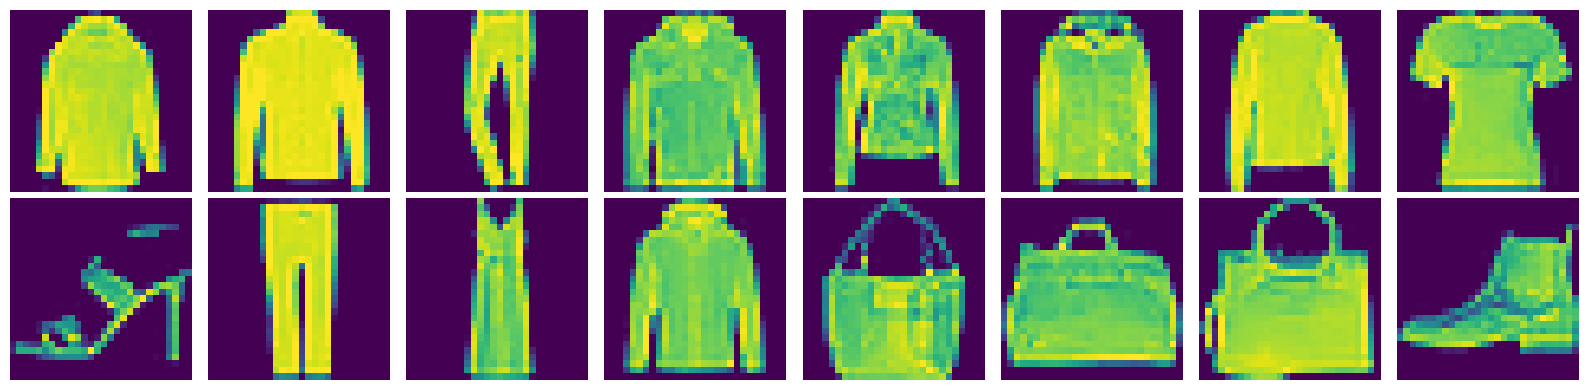

In [29]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    # img = generated[i].permute(1, 2, 0).numpy()
    # ax.imshow(img)
    img = generated[i].permute(1, 2, 0).squeeze(-1).numpy()
    ax.imshow(img)
    ax.axis('off')
# plt.suptitle("Generated CIFAR-10 samples")
plt.tight_layout()
plt.show()

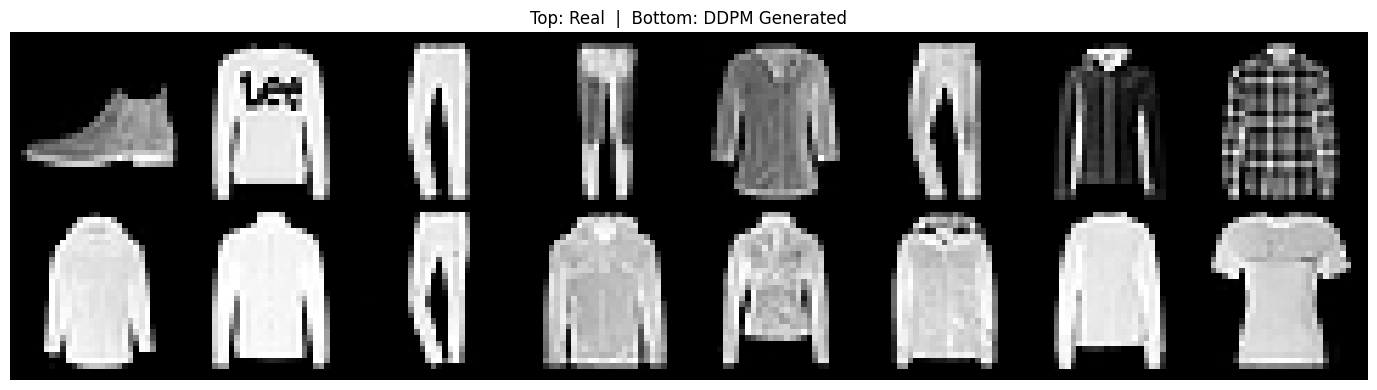

In [ ]:
real_imgs, real_lbls = next(iter(test_loader))
real_imgs = real_imgs[:8]                         

gen_imgs = generated[:8].float() / 255.0         

real_disp = (real_imgs.cpu() + 1) / 2             

comparison = torch.cat([real_disp, gen_imgs], dim=0)  

grid = make_grid(comparison, nrow=8, padding=2)  
fig, ax = plt.subplots(figsize=(16, 4))
ax.imshow(grid.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
ax.axis('off')
plt.title('Top: Real  |  Bottom: DDPM Generated')
plt.tight_layout()
plt.savefig('ddpm_real_vs_generated.png', dpi=150)
plt.show()